# Visualizar ejemplos de PlantVillage con TFDS

Este notebook descarga/carga el dataset `plant_village` usando `tensorflow_datasets`, selecciona 6 ejemplos de clases distintas, los muestra en una grilla de 3 imagenes por fila y guarda la figura en esta carpeta como `ejemplos_plant_village.png`.


In [ ]:
# Si falta alguna dependencia, ejecuta esta celda una vez y reinicia el kernel:
# %pip install tensorflow tensorflow-datasets matplotlib


In [10]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

OUTPUT_DIR = Path("dataset") if Path("dataset").is_dir() else Path.cwd()
OUTPUT_PATH = OUTPUT_DIR / "ejemplos_plant_village.png"

N_EXAMPLES = 6
N_COLS = 3
RANDOM_SEED = 42

OUTPUT_PATH


PosixPath('/Users/carolinachavez/convolutional-neuronal-network/dataset/ejemplos_plant_village.png')

## Cargar PlantVillage

La primera ejecucion puede tardar porque TFDS tiene que descargar y preparar el dataset.

In [11]:
ds, ds_info = tfds.load(
    "plant_village",
    split="train",
    with_info=True,
    shuffle_files=True,
)

label_names = ds_info.features["label"].names
print(f"Cantidad de clases: {len(label_names)}")
print(f"Cantidad de imagenes: {ds_info.splits['train'].num_examples}")


Cantidad de clases: 38
Cantidad de imagenes: 54303


## Ejemplo rapido con la visualizacion de TFDS

Esta celda usa la funcion que mencionaste. La figura final guardada se genera en las celdas siguientes para asegurar 6 clases distintas y 3 imagenes por fila.

2026-05-24 17:09:13.506154: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


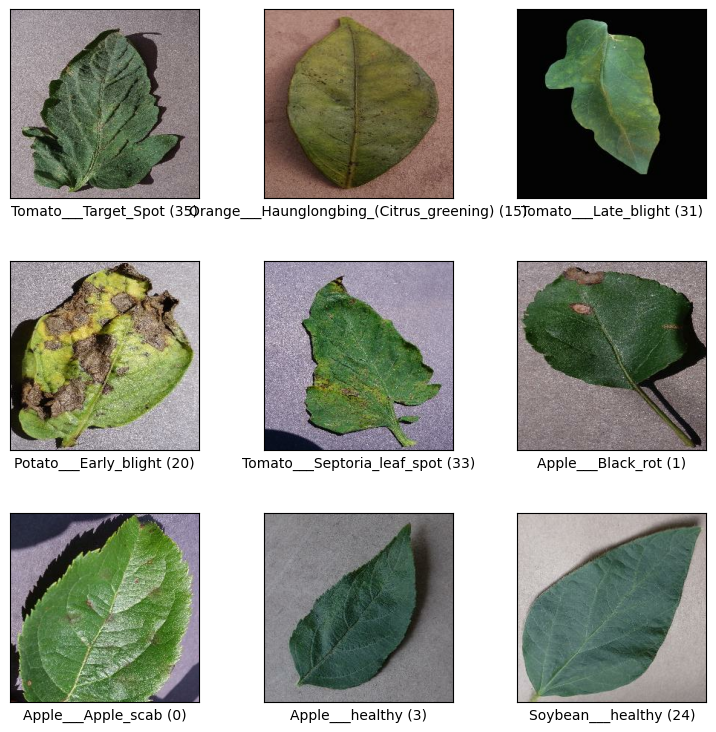

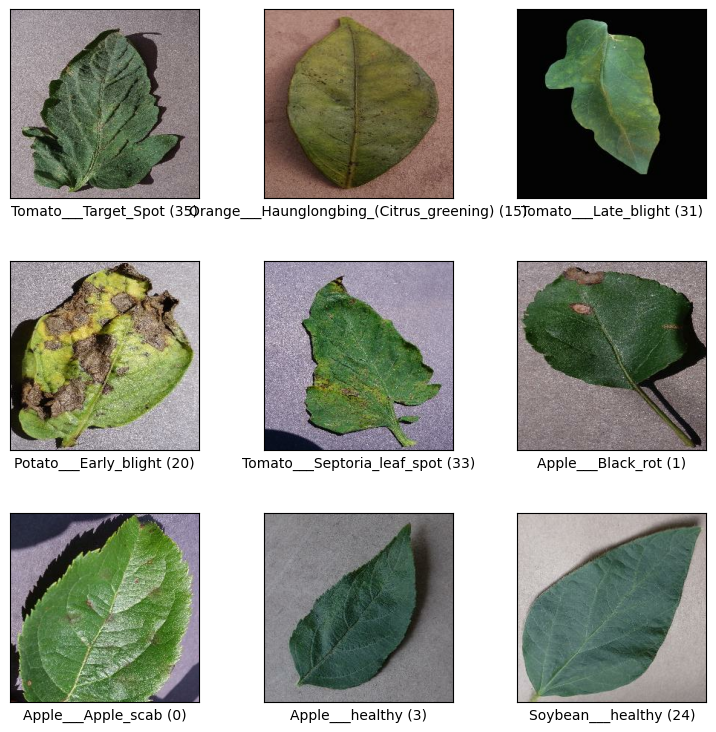

In [12]:
tfds.visualization.show_examples(ds, ds_info, is_batched=False)


## Seleccionar 6 clases distintas

In [13]:
rng = random.Random(RANDOM_SEED)
target_labels = set(rng.sample(range(len(label_names)), N_EXAMPLES))
selected_examples = {}

for example in ds.shuffle(10_000, seed=RANDOM_SEED):
    label_id = int(example["label"].numpy())
    if label_id in target_labels and label_id not in selected_examples:
        selected_examples[label_id] = example["image"].numpy()
    if len(selected_examples) == N_EXAMPLES:
        break

if len(selected_examples) < N_EXAMPLES:
    raise ValueError(
        f"Se esperaban {N_EXAMPLES} clases distintas, "
        f"pero solo se encontraron {len(selected_examples)}."
    )

selected_examples = sorted(selected_examples.items())
[(label_names[label_id], image.shape) for label_id, image in selected_examples]


[('Apple___Black_rot', (256, 256, 3)),
 ('Corn___Cercospora_leaf_spot Gray_leaf_spot', (256, 256, 3)),
 ('Corn___Common_rust', (256, 256, 3)),
 ('Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', (256, 256, 3)),
 ('Orange___Haunglongbing_(Citrus_greening)', (256, 256, 3)),
 ('Peach___healthy', (256, 256, 3))]

## Crear y guardar la imagen

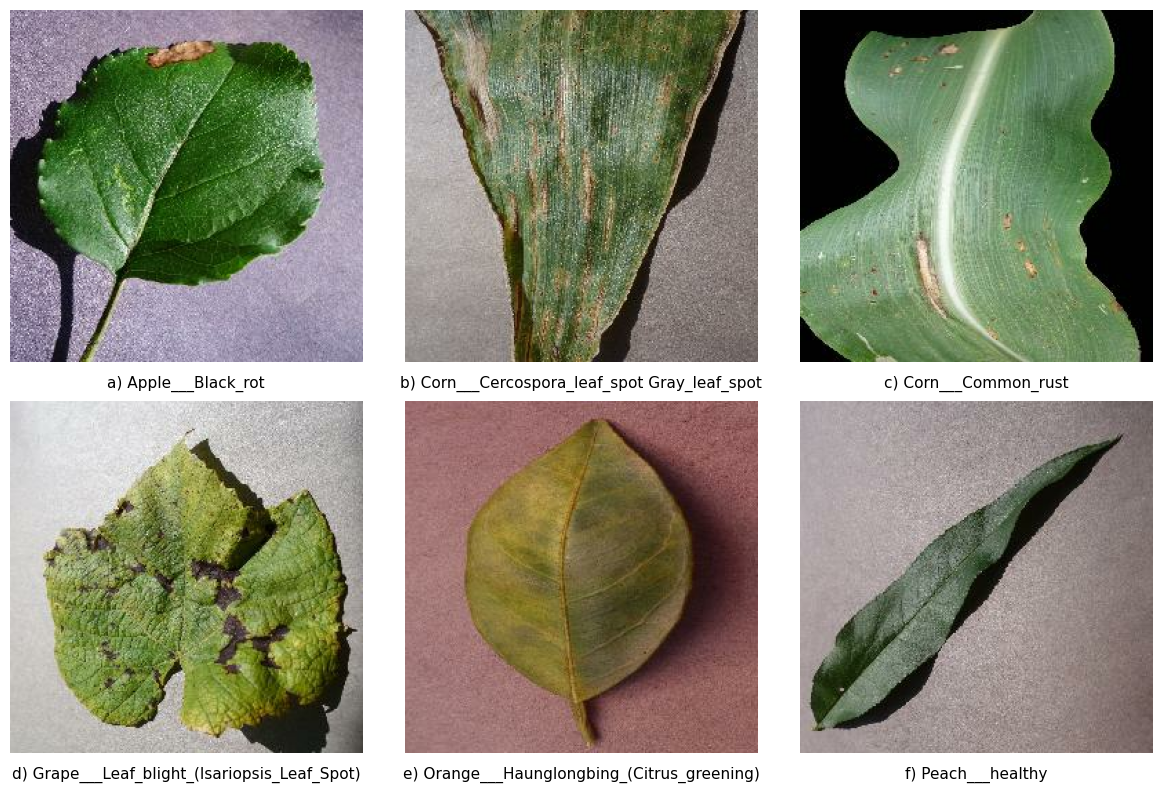

Imagen guardada en: /Users/carolinachavez/convolutional-neuronal-network/dataset/ejemplos_plant_village.png


In [14]:
n_rows = (N_EXAMPLES + N_COLS - 1) // N_COLS
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(12, 8))
axes = axes.flatten()

for index, (ax, (label_id, image)) in enumerate(zip(axes, selected_examples)):
    class_name = label_names[label_id]
    title_prefix = chr(ord("a") + index)
    ax.imshow(image)
    ax.set_xlabel(f"{title_prefix}) {class_name}", fontsize=11, labelpad=10)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

for ax in axes[len(selected_examples):]:
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUTPUT_PATH, dpi=200, bbox_inches="tight")
plt.show()

print(f"Imagen guardada en: {OUTPUT_PATH.resolve()}")
